# 15 — ROCKET / MiniROCKET: results exploration

Loads **`results/rocket_rskf_metrics.csv`** and **`rocket_rskf_summary.csv`** from **`14_rocket_poc.py`**.

**Run first:** `python 14_rocket_poc.py` (from `transformation_experiment/` or with `data/` visible). Options include **`--clf`** (`ridge`, `logreg`, `linear_svc`) and **`--threshold`** (`youden`, `f1`). Resume keys include both, so older CSV rows without these columns are treated as `ridge` + `youden`.


In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
RESULTS_DIR = EXPERIMENT_DIR / "results"
METRICS_PATH = RESULTS_DIR / "rocket_rskf_metrics.csv"
SUMMARY_PATH = RESULTS_DIR / "rocket_rskf_summary.csv"

print(RESULTS_DIR.resolve())
assert METRICS_PATH.exists(), f"Missing {METRICS_PATH} — run 14_rocket_poc.py first"
df = pd.read_csv(METRICS_PATH)
print(df.shape)
df.head()

/Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results
(315, 25)


,split_name,method,n_kernels,pr_auc,roc_auc,youden_threshold,sensitivity,precision,specificity,accuracy,...,tn,alpha_best,n_features,n_train,n_test,time_s,threshold_policy,classifier,ridge_alpha,clf_C
0,rep0_fold0,minirocket,2000,0.904588,0.956868,0.361809,0.864865,0.780488,0.940265,0.925400,...,425,1000.000000,1932,2252,563,2.072749,NaN,NaN,NaN,NaN
1,rep0_fold1,minirocket,2000,0.816543,0.904728,0.391960,0.765766,0.708333,0.922566,0.891652,...,417,1000.000000,1932,2252,563,1.359221,NaN,NaN,NaN,NaN
2,rep0_fold2,minirocket,2000,0.863804,0.908735,0.381910,0.830357,0.738095,0.926829,0.907638,...,418,1000.000000,1932,2252,563,1.407393,NaN,NaN,NaN,NaN
3,rep0_fold3,minirocket,2000,0.879987,0.945201,0.437186,0.857143,0.705882,0.911308,0.900533,...,411,1000.000000,1932,2252,563,1.408540,NaN,NaN,NaN,NaN
4,rep0_fold4,minirocket,2000,0.825328,0.915208,0.472362,0.830357,0.744000,0.929047,0.909414,...,419,215.443469,1932,2252,563,1.409389,NaN,NaN,NaN,NaN


## 1. Mean ± std by method and `n_kernels`


In [8]:
from IPython.display import display

metric_cols = [
    "pr_auc", "roc_auc", "f1", "sensitivity", "precision",
    "specificity", "youden_j",
]
gb_cols = ["method", "n_kernels"]
if "classifier" in df.columns and "threshold_policy" in df.columns:
    gb_cols = ["method", "n_kernels", "classifier", "threshold_policy"]

g = df.groupby(gb_cols, dropna=False)[metric_cols].agg(["mean", "std"])
g.columns = [f"{c}_{s}" for c, s in g.columns]
summary = g.reset_index()

def pm(row, col):
    m, s = row[f"{col}_mean"], row[f"{col}_std"]
    return f"{m:.4f} ± {s:.4f}"

rows = []
for _, r in summary.iterrows():
    row_dict = {
        "method": r["method"],
        "n_kernels": int(r["n_kernels"]),
        "PR-AUC": pm(r, "pr_auc"),
        "ROC-AUC": pm(r, "roc_auc"),
        "F1": pm(r, "f1"),
        "Sensitivity": pm(r, "sensitivity"),
        "Precision": pm(r, "precision"),
        "Youden J": pm(r, "youden_j"),
    }
    if "classifier" in summary.columns:
        row_dict["clf"] = r["classifier"]
        row_dict["thr"] = r["threshold_policy"]
    rows.append(row_dict)
display(pd.DataFrame(rows))
if SUMMARY_PATH.exists():
    display(pd.read_csv(SUMMARY_PATH))

,method,n_kernels,PR-AUC,ROC-AUC,F1,Sensitivity,Precision,Youden J,clf,thr
0,minirocket,500,0.8066 ± 0.0426,0.9002 ± 0.0233,0.7474 ± 0.0478,0.7382 ± 0.0750,0.7616 ± 0.0509,0.6801 ± 0.0705,logreg,f1
1,minirocket,2000,0.8581 ± 0.0370,0.9261 ± 0.0234,0.7794 ± 0.0302,0.8297 ± 0.0390,0.7354 ± 0.0305,0.7557 ± 0.0423,NaN,NaN
2,minirocket,10000,0.8532 ± 0.0328,0.9152 ± 0.0179,0.8113 ± 0.0265,0.7851 ± 0.0360,0.8412 ± 0.0389,0.7480 ± 0.0360,linear_svc,youden
3,minirocket,10000,0.8699 ± 0.0298,0.9265 ± 0.0172,0.7868 ± 0.0378,0.8360 ± 0.0333,0.7450 ± 0.0547,0.7639 ± 0.0418,logreg,youden
4,minirocket,10000,0.8702 ± 0.0286,0.9276 ± 0.0165,0.7795 ± 0.0353,0.8346 ± 0.0348,0.7329 ± 0.0495,0.7583 ± 0.0412,NaN,NaN
5,rocket,200,0.7434 ± 0.0432,0.8593 ± 0.0226,0.6605 ± 0.0401,0.7096 ± 0.0297,0.6197 ± 0.0618,0.6002 ± 0.0416,NaN,NaN
6,rocket,10000,0.7698 ± 0.0447,0.8863 ± 0.0229,0.6626 ± 0.0280,0.8183 ± 0.0360,0.5583 ± 0.0374,0.6565 ± 0.0363,linear_svc,youden
7,rocket,10000,0.8038 ± 0.0375,0.8880 ± 0.0216,0.7196 ± 0.0291,0.7656 ± 0.0376,0.6805 ± 0.0385,0.6759 ± 0.0388,logreg,youden
8,rocket,10000,0.7915 ± 0.0394,0.8803 ± 0.0233,0.7285 ± 0.0340,0.7180 ± 0.0540,0.7453 ± 0.0595,0.6554 ± 0.0472,NaN,NaN


,method,n_kernels,classifier,threshold_policy,pr_auc_mean,pr_auc_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,specificity_std,youden_j_mean,youden_j_std,time_s_mean,time_s_std
0,minirocket,500,logreg,f1,0.806637,0.042552,0.900155,0.023277,0.747434,0.047801,0.738176,0.074984,0.761600,0.050930,0.941947,0.018007,0.680123,0.070472,22.726322,3.795388
1,minirocket,2000,NaN,NaN,0.858050,0.036992,0.926148,0.023391,0.779392,0.030169,0.829698,0.038981,0.735360,0.030488,0.926003,0.010501,0.755701,0.042309,1.531458,0.303341
2,minirocket,10000,linear_svc,youden,0.853168,0.032816,0.915230,0.017934,0.811341,0.026546,0.785098,0.035975,0.841173,0.038929,0.962870,0.010806,0.747968,0.036002,109.720149,13.859994
3,minirocket,10000,logreg,youden,0.869932,0.029805,0.926481,0.017150,0.786810,0.037832,0.835999,0.033334,0.745009,0.054668,0.927911,0.021074,0.763910,0.041789,419.878867,174.381611
4,minirocket,10000,NaN,NaN,0.870220,0.028609,0.927649,0.016522,0.779511,0.035293,0.834574,0.034835,0.732926,0.049473,0.923700,0.019092,0.758274,0.041185,4.860625,23.055057
5,rocket,200,NaN,NaN,0.743361,0.043245,0.859258,0.022612,0.660517,0.040133,0.709604,0.029737,0.619705,0.061811,0.890547,0.024764,0.600151,0.041585,0.353618,0.261022
6,rocket,10000,linear_svc,youden,0.769785,0.044686,0.886300,0.022905,0.662622,0.027972,0.818271,0.035986,0.558294,0.037428,0.838238,0.026067,0.656509,0.036261,834.501823,1226.230641
7,rocket,10000,logreg,youden,0.803769,0.037547,0.888042,0.021648,0.719645,0.029143,0.765590,0.037597,0.680464,0.038525,0.910326,0.016190,0.675916,0.038786,708.148744,45.978989
8,rocket,10000,NaN,NaN,0.791453,0.039369,0.880309,0.023268,0.728529,0.034002,0.717952,0.054038,0.745277,0.059541,0.937399,0.021511,0.655351,0.047162,6.458034,0.268594


## 2. Dot plot: key metrics by configuration (max `n_kernels` per group)

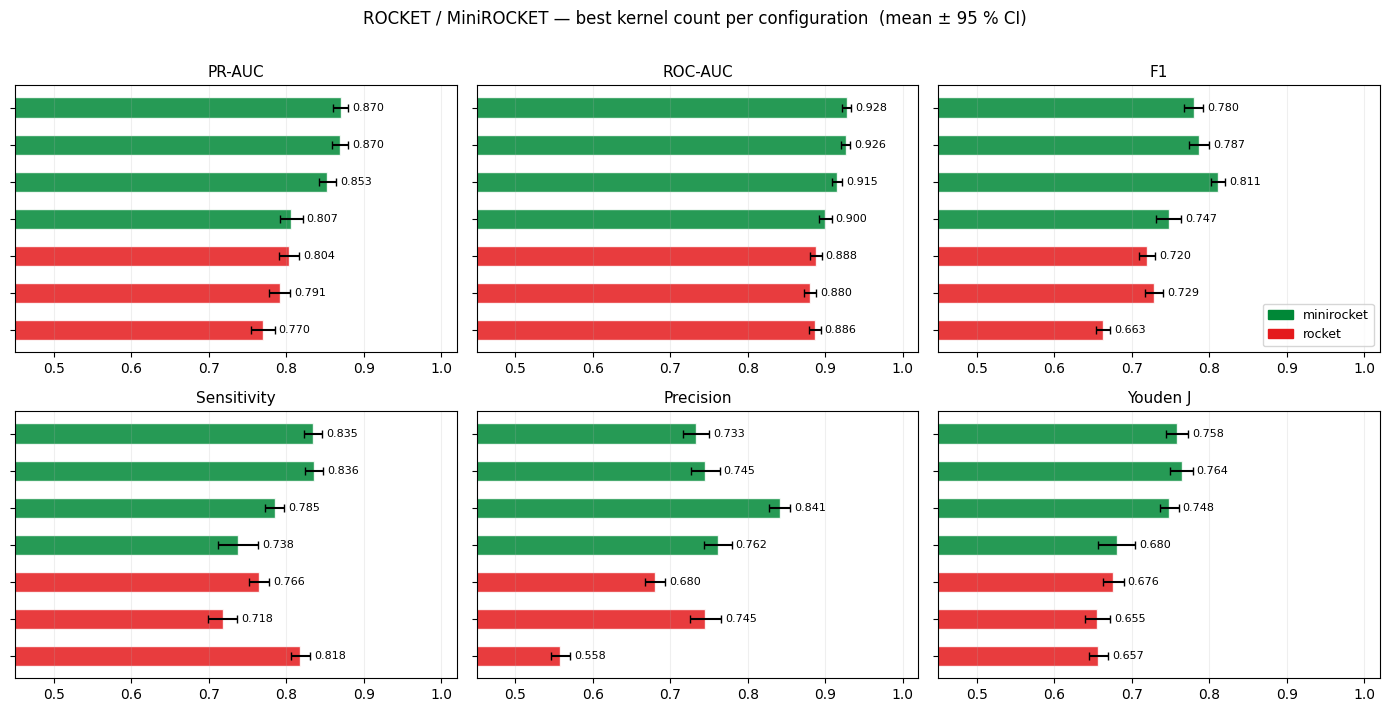

In [9]:
from scipy import stats

N_SPLITS = 35  # 7 reps × 5 folds
_t_crit = stats.t.ppf(0.975, N_SPLITS - 1)

# --- pick rows with largest n_kernels per (method, clf, thr) group ---
if "classifier" in summary.columns:
    idx = summary.groupby(
        ["method", "classifier", "threshold_policy"], dropna=False
    )["n_kernels"].idxmax()
    sub = summary.loc[idx].reset_index(drop=True)
else:
    idx = summary.groupby("method", dropna=False)["n_kernels"].idxmax()
    sub = summary.loc[idx].reset_index(drop=True)

# readable labels
def _label(r):
    clf = r.get("classifier", np.nan)
    thr = r.get("threshold_policy", np.nan)
    tag = f"{r['method']}  (nk={int(r['n_kernels'])})"
    if pd.notna(clf):
        tag += f"\n{clf}, {thr}"
    else:
        tag += "\nridge, youden"
    return tag

sub = sub.sort_values("pr_auc_mean", ascending=True).reset_index(drop=True)
labels = [_label(r) for _, r in sub.iterrows()]

# --- dot plot with 95 % CI ---
metrics = [
    ("pr_auc",      "PR-AUC"),
    ("roc_auc",     "ROC-AUC"),
    ("f1",          "F1"),
    ("sensitivity", "Sensitivity"),
    ("precision",   "Precision"),
    ("youden_j",    "Youden J"),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharey=True)
y = np.arange(len(sub))

# colour by method
method_colors = {"minirocket": "#008837", "rocket": "#e41a1c"}

for ax, (col, title) in zip(axes.flat, metrics):
    means = sub[f"{col}_mean"].values
    ci = _t_crit * sub[f"{col}_std"].values / np.sqrt(N_SPLITS)
    colors = [method_colors.get(m, "gray") for m in sub["method"]]

    ax.barh(y, means, xerr=ci, height=0.55, capsize=3,
            color=colors, edgecolor="white", alpha=0.85)
    # value annotation
    for yi, m, c in zip(y, means, ci):
        ax.text(m + c + 0.005, yi, f"{m:.3f}", va="center", fontsize=8)

    ax.set_yticks(y)
    ax.set_yticklabels(labels if ax == axes.flat[0] or ax == axes.flat[3] else [])
    ax.set_xlim(0.45, 1.02)
    ax.set_title(title, fontsize=11)
    ax.grid(True, axis="x", alpha=0.2)

# legend
from matplotlib.patches import Patch
handles = [Patch(color=c, label=l) for l, c in method_colors.items()]
axes[0, -1].legend(handles=handles, fontsize=9, loc="lower right")

fig.suptitle(
    "ROCKET / MiniROCKET — best kernel count per configuration  (mean ± 95 % CI)",
    fontsize=12, y=1.01,
)
fig.tight_layout()
plt.show()

## 3. Fold-level metric distributions

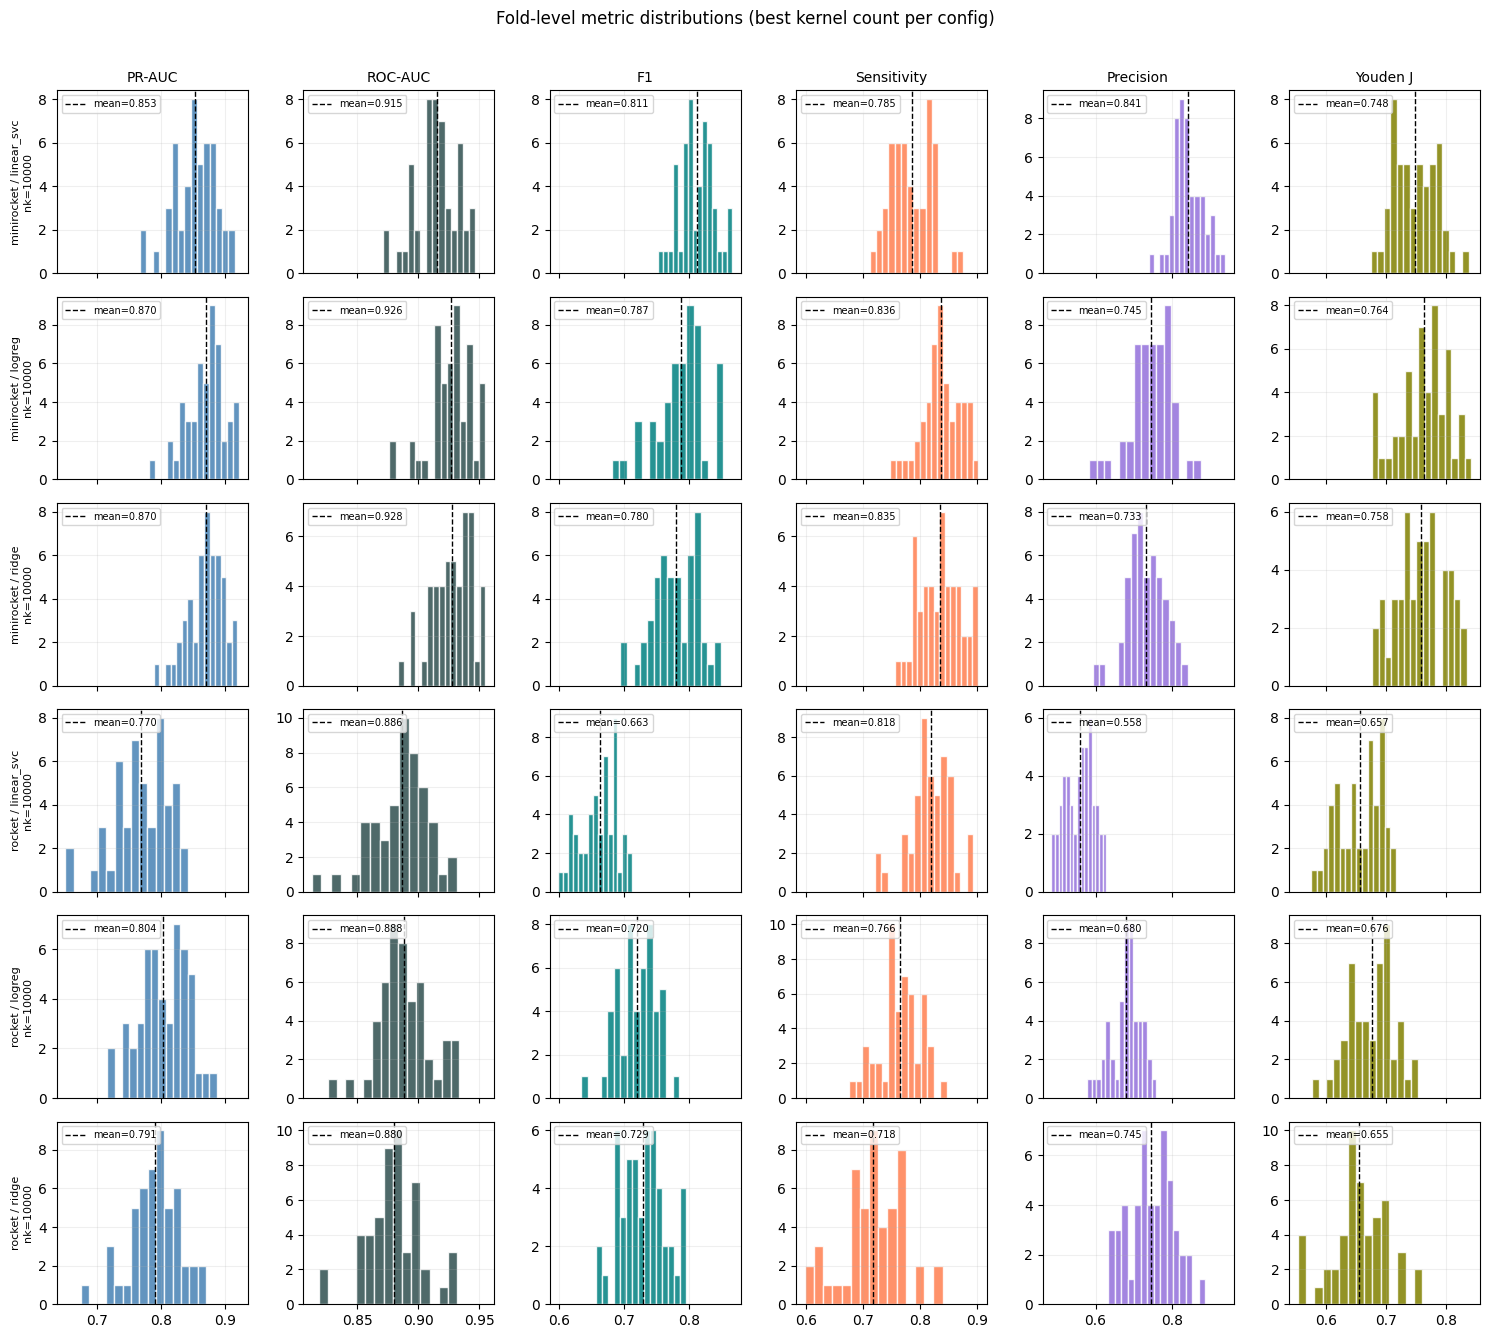

In [10]:
# Build a clean config label for every row in df
def _row_label(r):
    clf = r.get("classifier", np.nan)
    thr = r.get("threshold_policy", np.nan)
    tag = r["method"]
    if pd.notna(clf):
        tag += f" / {clf}"
    else:
        tag += " / ridge"
    return tag

df["config"] = df.apply(_row_label, axis=1)

# keep only the max-kernel rows for each config to avoid mixing kernel counts
max_nk = df.groupby("config", dropna=False)["n_kernels"].transform("max")
df_best = df[df["n_kernels"] == max_nk].copy()

hist_metrics = ["pr_auc", "roc_auc", "f1", "sensitivity", "precision", "youden_j"]
hist_titles  = ["PR-AUC", "ROC-AUC", "F1", "Sensitivity", "Precision", "Youden J"]
hist_colors  = ["steelblue", "darkslategray", "teal", "coral", "mediumpurple", "olive"]

configs = sorted(df_best["config"].unique())
n_cfg = len(configs)

fig, axes = plt.subplots(n_cfg, len(hist_metrics), figsize=(15, 2.2 * n_cfg),
                         sharex="col", sharey=False)
if n_cfg == 1:
    axes = axes[np.newaxis, :]

for row_i, cfg in enumerate(configs):
    mask = df_best["config"] == cfg
    nk = int(df_best.loc[mask, "n_kernels"].iloc[0])
    for col_i, (met, title, clr) in enumerate(zip(hist_metrics, hist_titles, hist_colors)):
        ax = axes[row_i, col_i]
        vals = df_best.loc[mask, met].dropna()
        ax.hist(vals, bins=15, color=clr, edgecolor="white", alpha=0.85)
        ax.axvline(vals.mean(), color="black", ls="--", lw=1, label=f"mean={vals.mean():.3f}")
        ax.legend(fontsize=7, loc="upper left")
        ax.grid(True, alpha=0.2)
        if row_i == 0:
            ax.set_title(title, fontsize=10)
        if col_i == 0:
            ax.set_ylabel(f"{cfg}\nnk={nk}", fontsize=8)

fig.suptitle("Fold-level metric distributions (best kernel count per config)", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()

## 4. Effect of kernel count on PR-AUC and ROC-AUC

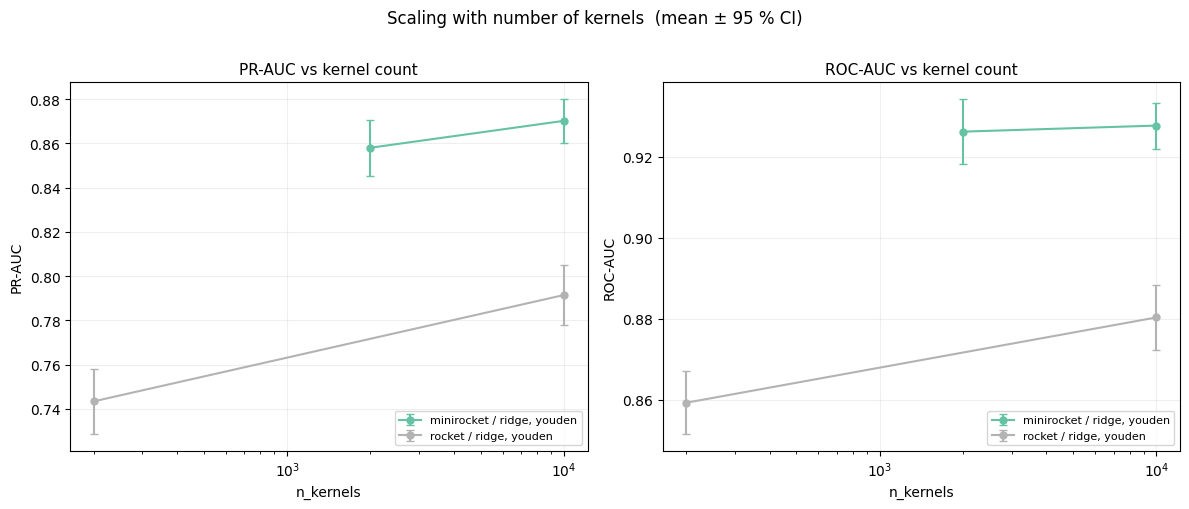

In [11]:
# For configs with >1 kernel count, show how PR-AUC / ROC-AUC scale
scale_metrics = [("pr_auc", "PR-AUC"), ("roc_auc", "ROC-AUC")]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Build config key without n_kernels
def _cfg_key(r):
    clf = r.get("classifier", np.nan)
    thr = r.get("threshold_policy", np.nan)
    tag = r["method"]
    if pd.notna(clf):
        tag += f" / {clf}, {thr}"
    else:
        tag += " / ridge, youden"
    return tag

summary["cfg_key"] = summary.apply(_cfg_key, axis=1)

# only groups with >1 kernel count
multi = summary.groupby("cfg_key").filter(lambda g: g["n_kernels"].nunique() > 1)

cfg_keys = sorted(multi["cfg_key"].unique())
cmap = plt.cm.Set2(np.linspace(0, 1, max(len(cfg_keys), 1)))

for ax, (col, title) in zip(axes, scale_metrics):
    for i, key in enumerate(cfg_keys):
        g = multi[multi["cfg_key"] == key].sort_values("n_kernels")
        means = g[f"{col}_mean"].values
        ci = _t_crit * g[f"{col}_std"].values / np.sqrt(N_SPLITS)
        ax.errorbar(g["n_kernels"], means, yerr=ci,
                    fmt="o-", ms=5, capsize=3, label=key, color=cmap[i])
    ax.set_xlabel("n_kernels")
    ax.set_ylabel(title)
    ax.set_title(f"{title} vs kernel count", fontsize=11)
    ax.legend(fontsize=8, loc="lower right")
    ax.grid(True, alpha=0.2)
    ax.set_xscale("log")

fig.suptitle("Scaling with number of kernels  (mean ± 95 % CI)", fontsize=12, y=1.01)
fig.tight_layout()
plt.show()